# Causal Mediation Analysis II: Explaining LLMs

In this tutorial, we'll walk through how to apply **causal mediation analysis** to uncover the internal processes of LLMs.

Before we begin, we encourage you to read through [causal mediation analysis](https://) introductory tutorial, which goes over key concepts in causal mediation analysis and uses them to explain a toy arithmetic neural network.

In this tutorial, we'll broaden our horizons to explain an LLM. Along the way, we'll cover:
* **Information flow**: how to track the passage of information from the input to the output.
* **Attention head plots**: understanding which components might be responsible for model behavior.
* **Gender bias in LMs**: what causal mediation analysis can teach us about bias in LMs.

📗 Prefer to use Colab? Follow the tutorial [here](https://colab.research.google.com/drive/1ZHU5jkK2sTlqqf4T52FG1a7KDJ_z7R3Q)!

## 0️⃣ Setup

In [1]:
from IPython.display import clear_output

# install nnsight to analyze neural network internals
!pip install -U nnsight

clear_output()

**Note**

The original version of this tutorial uses the gated Llama-3.2 1B Instruct model. This adapted notebook uses the ungated **TinyLlama-1.1B-Chat-v1.0** model, so no Hugging Face access request is needed. The patching code is the same, but a few lines have been updated for nnsight 0.7.x.

In [2]:
# No login is required for TinyLlama, but if you switch back to a gated model later,
# you can log in with your Hugging Face token:
# from huggingface_hub import login
# login(token='hf_...')

In [3]:
# load model
import nnsight
from IPython.display import clear_output

model = nnsight.LanguageModel(
    'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
    #'meta-llama/Llama-3.2-1B',
    device_map='auto'
)

clear_output()
print('Loaded:', model.config._name_or_path)

Loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0


## 1️⃣ Causal mediation & information flow

In this tutorial, we'll apply causal mediation analysis to understand how an LLM recalls information about cities. For example, when we start a sentence with "Paris is in the city of ____", an LLM knows that the next token is "France". Where does the model store this information?

In [4]:
# does our model know where Paris is?
import torch

base_prompt = "Paris is in the country of"

with torch.no_grad():
    with model.trace(base_prompt):
        # get logits over final token
        base_logits = model.output.logits[:, -1, :].save()

predicted_token_id = base_logits.argmax(dim=-1).item()
print('Prompt:', base_prompt)
print(f'Model completion: {model.tokenizer.decode(predicted_token_id)!r}')

Loading weights: 100%|███████████| 201/201 [00:00<00:00, 25885.20it/s]


Prompt: Paris is in the country of
Model completion: 'France'


Somewhere, somehow, our model stores information about Paris that allows it to recall the country France. Can we **intervene** on the neurons that mediate the connection between Paris and France to make our model think the Paris is in a completely different country, like Brazil?

To do this, we'll follow the same **causal mediation analysis** steps that we covered in the [previous tutorial](https://).

First, create a **base** and **source** pair where only the city changes. Then, at each layer and token position,
1. Run a forward pass on the **source input** and store the value of the model's activation.
2. Run a forward pass on the **base input** and **intervene** on the activation by patching in its source value from (1).
3. Collect the result of the **intervened run** and check - did patching change the value of the base output?

![animation copying over a residual stream token from "Rio is in" to "Paris is in"](https://github.com/AmirZur/nnsight-tutorials/blob/main/figures/patching_animation.gif?raw=true)

We'll use Paris and Rio as our base and source cities.

In [5]:
base_prompt = "Paris is in the country of"
source_prompt = "Rio is in the country of"

Let's go through causal mediation analysis step by step!

In [6]:
# 1. collect source activations
source_hidden_states = []

with torch.no_grad():
    with model.trace(source_prompt):
        # get hidden states of all layers in the network
        # we index the output at 0 because it's a tuple where the first index is the hidden state
        # (use an explicit for-loop so nnsight 0.7.x exposes the saved tensors outside the block)
        for layer in model.model.layers:
            source_hidden_states.append(layer.output[0].save())

This step might take 1-2 minutes, because we're looping through layers & token positions.

In [7]:
# 2 and 3. intervene and collect intervention results

# we'll keep track of the probability of outputing Brazil vs. the probability of outputing France
# Tokenizers differ, so take the last token of the target string.
def get_token_id(tokenizer, text):
    return tokenizer.encode(text, add_special_tokens=False)[-1]

source_country = get_token_id(model.tokenizer, " Brazil")  # includes a space
base_country = get_token_id(model.tokenizer, " France")  # includes a space

num_tokens = len(model.tokenizer(base_prompt, add_special_tokens=False).input_ids)  # get number of tokens in prompt

causal_effects = []
# iterate through all the layers
for layer_idx in range(model.config.num_hidden_layers):
    causal_effect_per_layer = []
    # iterate through all tokens
    for token_idx in range(num_tokens):
        with torch.no_grad():
            with model.trace(base_prompt) as tracer:
                # 2. change the value of the base activation to the source value
                # In nnsight 0.7.x with batch_size=1, layer.output[0] is 2-D [seq_len, hidden_size]
                model.model.layers[layer_idx].output[0][token_idx, :] = \
                    source_hidden_states[layer_idx][token_idx, :]

                # 3. get intervened output & compare to base output
                intervened_logits = model.output.logits[:, -1, :]
                intervened_probs = intervened_logits.softmax(dim=-1)
                # in this case, we'll keep track of how much we changed
                # towards Brazil & away from France -> the higher, the more causal effect!
                intervened_prob_diff = (intervened_probs[0, source_country] - intervened_probs[0, base_country]).item().save()

            causal_effect_per_layer.append(intervened_prob_diff)
    causal_effects.append(causal_effect_per_layer)

Let's check out our results! The **darker** a cell is, the **greater the difference** between $p(``Brazil")$ and $p(``France")$, and hence the **more causal effect** the residual stream at that layer / token position has on mediating the path between the city and its country.

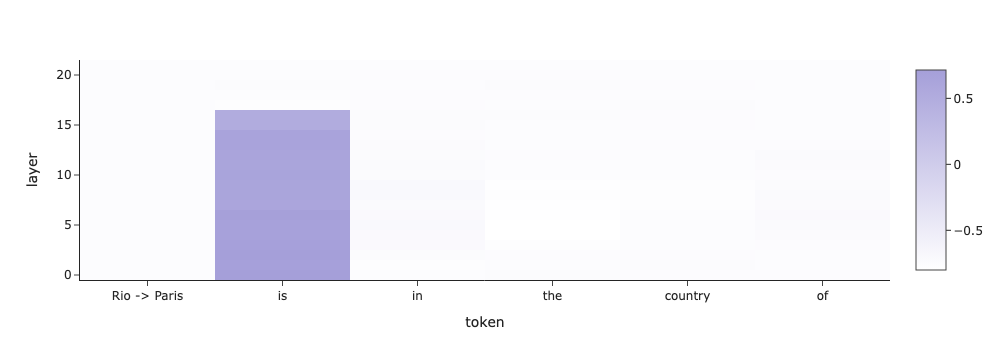

In [8]:
# visualize our results!
import plotly.express as px

# Build token labels dynamically so they match this model's tokenizer.
token_ids = model.tokenizer(base_prompt, add_special_tokens=False).input_ids
token_labels = [model.tokenizer.decode([tok]) for tok in token_ids]
if len(token_labels) > 0:
    token_labels[0] = f"Rio -> {token_labels[0]}"

fig = px.imshow(
    causal_effects,
    x=token_labels,
    y=list(range(model.config.num_hidden_layers)),
    template='simple_white',
    color_continuous_scale=[[0, '#FFFFFF'], [1, "#A59FD9"]]
)

fig.update_layout(
    xaxis_title='token',
    yaxis_title='layer',
    yaxis=dict(autorange='min')
)

fig

Let's break this plot down. These type of residual stream causal mediation plots come up a lot, so they're useful to understand! (for example, see the [applied tutorial](https://nnsight.net/notebooks/mini-papers/marks_geometry_of_truth/) on geometry of truth!)

We'll start from the lower layers and work our way up.

1. **Total effect**: at the very first layer, the city token ("Rio" -> "Paris") has a causal effect. This makes sense, since it corresponds to the **total effect** of the input - changing just that token in the input changes the model's prediction of the next token.

2. **Intermediate tokens**: in this example, the other tokens in the sentence (up until the last one) _don't_ have significant causal effect. Depending on your intuition, this also might make some sense - the model isn't storing any information related to Paris in those tokens.

3. **Final layers of city token**: this is where things start to get interesting. At the very last layers (some layer and above), changing the residual stream from "Paris" to "Rio" doesn't actually change the model's output! In a sense, the information is "no longer there", or rather, the model no longer has need for it, so it doesn't get used. Where did the information about Paris' country go then?

4. **Final layers of final token**: at some point, the model has to output the next token! And with modern autoregressive models, only the information in the final token can be used in the final layer. Hence, at some point during computation, the model must **move information** from previous tokens into the final token position. That's what's likely going on at layer 9! (keep this layer number in mind - we'll return to it soon).

Information flow plots are a great way to visualize **where** interesting computation is happening in the model. It doesn't quite tell us **how** the model is going about solving the task, but it does help us understand which components to inspect!

Next, we'll try to look into the "how" a little more by patching specific components in the model. We'll do a search over the entire model, but you might already be able to guess which layers will contain the mechanism we're looking for.

## 2️⃣ Intervening on specific model components

In the last section, we saw how residual stream patching can help us identify where information flows within a language model. In this section, we'll go a step deeper and try to find the components responsible for moving this information. It will lead to some very pretty-looking attention plots!

We know that our language model has to move information from the city token to the final token before it can predict the next token in the sequence. Yet there's only one type of component that's able to perform this operation: attention heads. This ability to move information betweent tokens make attention heads quite powerful, and a useful component to analyze when interpreting a model's behavior.

Thankfully, causal mediation analysis is agnostic to our selection of model component! We can follow the same steps to find attention heads that causally mediate the recalling of a city's country. For each attention head, we will
1. Run a forward pass on the **source input** and store the value of the head's activation.
2. Run a forward pass on the **base input** and **intervene** on the head's  activation by patching in its source value from (1).
3. Collect the result of the **intervened run** and check - did patching the attention head change the value of the base output?

In [9]:
# 1. collect source activations
source_hidden_states = []

with torch.no_grad():
    with model.trace(source_prompt):
        # index into attention head outputs
        # (note: we chose the o-projection input,
        # but you can try intervening on q/k/v-proj too!)
        for layer in model.model.layers:
            source_hidden_states.append(layer.self_attn.o_proj.input.save())

We need to change some small things to make sure that we're indexing into the right attention head, but otherwise it's almost the same code as the residual stream interventions in the previous section!

In [10]:
# 2 and 3. intervene and collect intervention results

# we'll keep track of the probability of outputing Brazil vs. the probability of outputing France
source_country = get_token_id(model.tokenizer, " Brazil")  # includes a space
base_country = get_token_id(model.tokenizer, " France")

attn_dim = model.config.hidden_size // model.config.num_attention_heads

causal_effects = []
# iterate through all the layers
for layer_idx in range(model.config.num_hidden_layers):
    causal_effect_per_layer = []
    # iterate through all tokens
    for head_index in range(model.config.num_attention_heads):
        with torch.no_grad():
            with model.trace(base_prompt) as tracer:
                # 2. change the value of the base activation to the source value
                attention_value = model.model.layers[layer_idx].self_attn.o_proj.input
                # change value only at attention head index (across all tokens)
                attention_value[:, :, head_index * attn_dim:(head_index + 1) * attn_dim] = \
                source_hidden_states[layer_idx][:, :, head_index * attn_dim:(head_index + 1) * attn_dim]

                # put attention head back in
                model.model.layers[layer_idx].self_attn.o_proj.input = attention_value

                # 3. get intervened output & compare to base output
                intervened_logits = model.output.logits[:, -1, :]
                intervened_probs = intervened_logits.softmax(dim=-1)
                # in this case, we'll keep track of how much we changed
                # towards Brazil & away from France -> the higher, the more causal effect!
                intervened_prob_diff = (intervened_probs[0, source_country] - intervened_probs[0, base_country]).item().save()

            causal_effect_per_layer.append(intervened_prob_diff)
    causal_effects.append(causal_effect_per_layer)

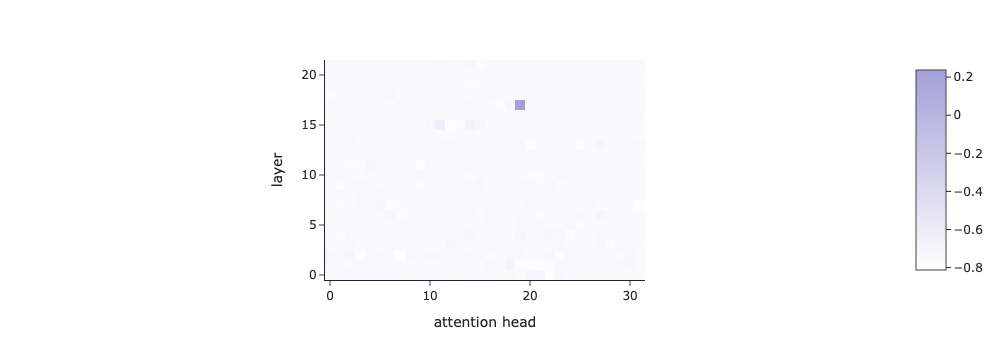

In [11]:
# visualize our results!
import plotly.express as px

fig = px.imshow(
    causal_effects,
    x=list(range(model.config.num_attention_heads)),
    y=list(range(model.config.num_hidden_layers)),
    template='simple_white',
    color_continuous_scale=[[0, '#FFFFFF'], [1, "#A59FD9"]]
)

fig.update_layout(
    xaxis_title='attention head',
    yaxis_title='layer',
    yaxis=dict(autorange='min')
)

fig

Behold! We found the culprit in recalling Paris' country - attention head #23 in layer #9 (see? We told you that this layer will make a return!) seems to solely mediate the model's ability to recall the country of Paris.

Let's try intervening on this attention head to see how much this generalizes.

In [12]:
# to what extent does head 9.23 mediate the model's ability to recall countries?
# (For TinyLlama, update LAYER/HEAD to whatever looked strongest in your heatmap.)
LAYER = 9
HEAD = 7

# try out different cities to see if we localized the right component!
new_base_prompt = 'London is in the country of'
new_source_propmt = 'Berlin is in the country of'

# collect source activations
new_source_hidden_state = None
with torch.no_grad():
    with model.trace(new_source_propmt):
        # index into attention head outputs
        # (note: we chose the o-projection input,
        # but you can try intervening on q/k/v-proj too!)
        new_source_hidden_state = \
            model.model.layers[LAYER].self_attn.o_proj.input[:, :, HEAD * attn_dim:(HEAD + 1) * attn_dim].save()

with torch.no_grad():
    with model.trace(new_base_prompt) as tracer:
        # 2. change the value of the base activation to the source value
        attention_value = model.model.layers[LAYER].self_attn.o_proj.input
        # change value only at attention head index (across all tokens)
        attention_value[:, :, HEAD * attn_dim:(HEAD + 1) * attn_dim] = new_source_hidden_state
        # put attention head back in
        model.model.layers[LAYER].self_attn.o_proj.input = attention_value

        output = model.output.logits[:, -1, :].argmax(dim=-1).item().save()

print(f'{new_source_propmt.split()[0]} -> {new_base_prompt.split()[0]}')
print(f'Intervened output: {model.tokenizer.decode(output)!r}')

Berlin -> London
Intervened output: 'England'


It certainly doesn't generalize to everything, but we certainly found a meaningful component! Narrowing it down from 16 layers x 32 attention heads into a singular attention head component that mediates the recall of a city's country - not too shabby!

Although we won't go into it here, we could imagine continuing the analysis by intervening on MLP components as well. This is especially useful if we want to study knowledge editing, because research suggests that MLP layers play a key role in factual recall. We encourage you to try it out on your own! The code will follow the same template as we set up for intervening on residual stream and attention head activations.

## *️⃣ Extension: gender bias in GPT-2

In this exercise, we'll try to roughly recreate Figure 5a from [Vig et al. 2020](https://arxiv.org/abs/2004.12265), which applied causal mediation analysis to investigate gender bias in GPT-2 (and largely inspired this and the previous tutorials!).

In [13]:
# delete previous model to save GPU space
import gc
import torch

del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    torch.mps.empty_cache()

Hopefully this section will show that we still have lots to learn from GPT-2-sized models!

In [14]:
# load model
import nnsight
from IPython.display import clear_output

model = nnsight.LanguageModel(
    'gpt2',
    device_map='auto'
)

clear_output()
print('Loaded:', model.config._name_or_path)

Loaded: gpt2


The way we'll assess gender bias here is through "winogender" sentences, which are Winograd sentences that purposefully induce ambiguity about the subject of the sentence.

In [15]:
winogender_sentence = "The nurse examined the farmer for injuries because she was"

stereotypical_completion = " caring" # ("she" refers to the nurse)
antistereotypical_completion = " screaming" # ("she" refers to the farmer)

Let's see how GPT-2 does in resolving the subject of the sentence. We'll measure the probabilities over each completion to get a sense of which one was more likely.

In [16]:
stereotypical_token = model.tokenizer(stereotypical_completion).input_ids[0]
antistereotypical_token = model.tokenizer(antistereotypical_completion).input_ids[0]

with torch.no_grad():
    with model.trace(winogender_sentence):
        probs = model.output.logits[:, -1, :].softmax(dim=-1)
        stereotypical_probability = probs[0, stereotypical_token].item().save()
        antistereotypical_probability = probs[0, antistereotypical_token].item().save()

print('stereotypical_probability:', stereotypical_probability)
print('antistereotypical_probability:', antistereotypical_probability)
print('ratio:', stereotypical_probability / antistereotypical_probability)

Loading weights: 100%|███████████| 148/148 [00:00<00:00, 82911.31it/s]


stereotypical_probability: 0.0006785767036490142
antistereotypical_probability: 0.0003285189741291106
ratio: 2.065563200566699


Right off the bat, the case doesn't look great for GPT-2. Although both prbabilities are low, the stereotypical completion is twice as likely as the antistereotypical completion!

But okay, let's cut GPT-2 some slack. After all, neither completion is that likely. Let's see what happens when we try to resolve the ambiguity: what if we replace "nurse" with "man", so that "she" has to refer to the screaming farmer?

In [17]:
resolved_sentence = "The man examined the farmer for injuries because she was"

with torch.no_grad():
    with model.trace(resolved_sentence):
        probs = model.output.logits[:, -1, :].softmax(dim=-1)
        stereotypical_probability = probs[0, stereotypical_token].item().save()
        antistereotypical_probability = probs[0, antistereotypical_token].item().save()

print('stereotypical_probability:', stereotypical_probability)
print('antistereotypical_probability:', antistereotypical_probability)
print('ratio:', stereotypical_probability / antistereotypical_probability)

stereotypical_probability: 0.00018060271395370364
antistereotypical_probability: 0.001235542818903923
ratio: 0.14617276810683116


This time, the ratio flipped! The stereotypical response is much less likely, because GPT-2 seems to understand that "she" refers to the farmer in pain, and not to the man examining her. This means that, by default, GPT-2 seemed to assume that the gender of the nurse was female, and when we explicitly referred to the nurse as a man, GPT-2 flipped its predictions around.

This may not be that good for the model, but it's good for us: we can use the distinction between "nurse" and "man" as our base and our source in order to localize the GPT-2's representation of nurses as females.

We'll get you started, but this time let's see if you can complete the code! We'll be intervening on the `c_proj` component in GPT-2's attention head. Otherwise, everything should look roughly similar to how we intervened on the Llama model earlier in this tutorial.

In [18]:
base_prompt = "The nurse examined the farmer for injuries because she was"
source_prompt = "The man examined the farmer for injuries because she was"

In [19]:
# 1. collect source activations (we wrote this one for you)
source_hidden_states = []

with torch.no_grad():
    with model.trace(source_prompt):
        # index into attention head outputs
        # (note: we chose the o-projection input,
        # but you can try intervening on q/k/v-proj too!)
        for layer in model.transformer.h:
            source_hidden_states.append(layer.attn.c_proj.input.save())

In [20]:
# 2 and 3. intervene and collect intervention result
# (completed solution for the exercise above)

attn_dim = model.config.n_embd // model.config.n_head

causal_effects = []
# iterate through all the layers
for layer_idx in range(model.config.n_layer):
    causal_effect_per_layer = []
    # iterate through all tokens
    for head_index in range(model.config.n_head):
        with torch.no_grad():
            with model.trace(base_prompt) as tracer:
                # 2. change the value of the base activation to the source value
                attention_value = model.transformer.h[layer_idx].attn.c_proj.input
                attention_value[:, :, head_index * attn_dim:(head_index + 1) * attn_dim] = \
                    source_hidden_states[layer_idx][:, :, head_index * attn_dim:(head_index + 1) * attn_dim]
                model.transformer.h[layer_idx].attn.c_proj.input = attention_value

                # 3. get intervened output & compare to base output
                intervened_logits = model.output.logits[:, -1, :]
                intervened_probs = intervened_logits.softmax(dim=-1)
                # compare the probs between the antistereotypical and stereotypical completion
                intervened_prob_diff = (
                    intervened_probs[0, stereotypical_token] - intervened_probs[0, antistereotypical_token]
                ).item().save()

            causal_effect_per_layer.append(intervened_prob_diff)
    causal_effects.append(causal_effect_per_layer)

Let's see how we did! We can compare the plot to Figure 5a in [Vig et al. 2020](https://arxiv.org/abs/2004.12265). The authors used a much bigger dataset than our single example, so we might not expect to get the exact same results. Still, one or two attention heads might be related!

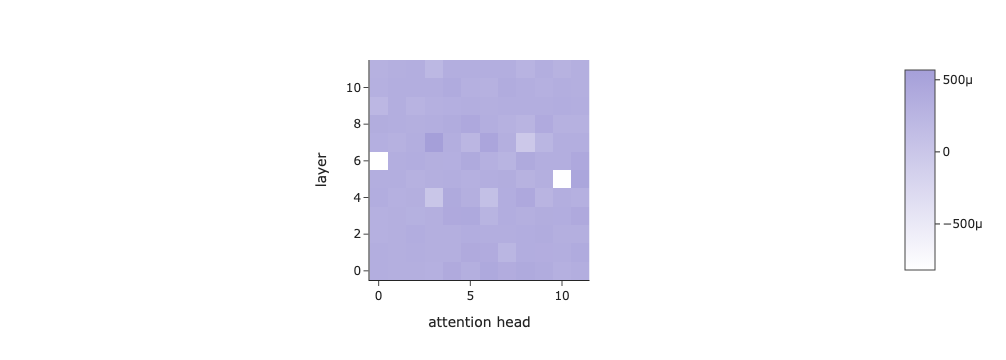

In [21]:
# visualize our results!
import plotly.express as px

fig = px.imshow(
    causal_effects,
    x=list(range(model.config.n_head)),
    y=list(range(model.config.n_layer)),
    template='simple_white',
    color_continuous_scale=[[0, '#FFFFFF'], [1, "#A59FD9"]]
)

fig.update_layout(
    xaxis_title='attention head',
    yaxis_title='layer',
    yaxis=dict(autorange='min')
)

fig

Checking your work: our implementation didn't recover the importance of head 8.5 like in Figure 5a (perhaps other examples were more affected by that attention head). However, we did see a causal effect for heads 0.6 and 10.5, which the original paper picked up on as well!

If you're curious, we strongly encourage reading through [Vig et al. 2020](https://arxiv.org/abs/2004.12265). The following experiment in the paper tries to correct for gender bias by ablating the attention heads responsible. We encourage you to try it out! If you have a replication that you like, please reach out to the `nnsight` / NDIF team - we'd love for people to contribute to the tutorial notebooks on the `nnsight` website!

In this tutorial, we applies the concepts of causal analysis to analyze an LLM - and get it to change what it knows about cities! If you're curious about knowledge editing and more powerful intervention techniques, we encourage you to check out the [DAS](https://nnsight.net/notebooks/tutorials/DAS) tutorial next! If you want to explore a different but related form of causal analysis, check out the tutorial on [causal abstraction](https://), which walks through how to interpret a model when you already have a hypothesis in mind.